<p style="text-align: center">
<img src="../../../assets/images/dtlogo.png" alt="Duckietown" width="50%">
</p>

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

TASK_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if TASK_ROOT not in sys.path:
    sys.path.insert(0, TASK_ROOT)

# Implementation of Braitenberg agent

Now we know enough about image filtering to implement our Braitenberg agent such that it will avoid duckies.  You already updated the image preprocessing in the last activity to highlight duckies - now it's time to handle the sensorimotor connections in order to control our agent.

### Setup

We will implement an agent of the form

```python
left_motor  = const + gain *  np.sum( LEFT * preprocess(image) )
right_motor = const + gain *  np.sum( RIGHT * preprocess(image) )
```

where `LEFT` and `RIGHT` are the weight matrices, while `const` and `gain` are two extra parameters for fine tuning.

To do this you will have to implement the two functions `get_motor_left_matrix()` and `get_motor_right_matrix()` in the file [connections.py](../../packages/connections.py).

The other important code, which you need to **not** touch (for now), is the file [agent.py](../../packages/agent.py). This contains the rest of the Braitenberg agent, including all of the functionality (reading observations and creating motor commands). The agent will load the `get_motor_left_matrix`, `get_motor_right_matrix` functions from the file [connections.py](../../packages/connections.py).


### Visualization
Before you jump into editing the code, we can also load the functions from `connections.py` into this notebook to visualize their output:

In [2]:
from packages.connections import get_motor_left_matrix, get_motor_right_matrix

Let's visualize what the functions above are doing. As we said, the defaults do not make much sense, so not we won't see anything interesting. But as you go and change the functions, then you will see more interesting results. You can come back to this notebook as you fine-tune your solution to see the updates. We'll start with the duckie image once again.

**Note: you might need to reload the kernel for the notebook to detect the changes you make.**

In [3]:
fn = '../../../assets/samples/big-duck/big-duck-10.jpg'
image1 = plt.imread(fn)
image1_gray = np.mean(image1, axis=2)
shape = image1_gray.shape
print(shape)

(480, 640)


The `shape` that was just printed above will be useful to you when you edit [connections.py](../../packages/solution/connections.py) as well as the visualizations of the motor matrices below.

In [4]:
L = get_motor_left_matrix(shape)
R = get_motor_right_matrix(shape)

Text(0.5, 1.0, 'right matrix')

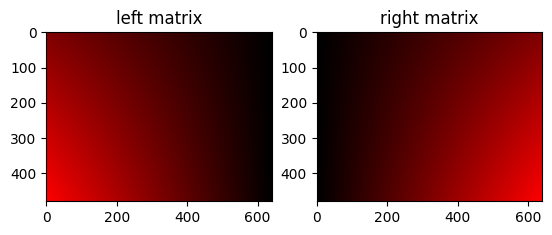

In [5]:
def posneg(matrix):
    """Visualize a matrix: positive values in red, negative in blue, zero is black."""
    m = np.max(np.abs(matrix))
    if m == 0:
        return np.zeros((*matrix.shape, 3), dtype=np.uint8)
    normalized = matrix / m  # range [-1, 1]
    img = np.zeros((*matrix.shape, 3), dtype=np.uint8)
    img[:, :, 0] = np.clip(normalized * 255, 0, 255).astype(np.uint8)   # red for positive
    img[:, :, 2] = np.clip(-normalized * 255, 0, 255).astype(np.uint8)  # blue for negative
    return img

# Visualizing left and right matrices
# Red = positive weights, blue = negative weights
f = plt.figure()
f.add_subplot(1, 2, 1)
plt.imshow(posneg(L))
plt.title('left matrix')
f.add_subplot(1, 2, 2)
plt.imshow(posneg(R))
plt.title('right matrix')

The following code will run the algorithm against some test images.

Note that it is not possible to really test such an algorithm on passive data. We need to run it!

Still, it is useful to see how your matrices are used. We simply multiply them with the preprocessed image
(the image that now only has non-zero pixel values where there are duckies). Then, we look at the sign of the result for
each matrix, and this is what decides which control values get sent to the motors.

Think about how to value your matrices such that the sign of their multiplication's results is a good control rule for your motors.

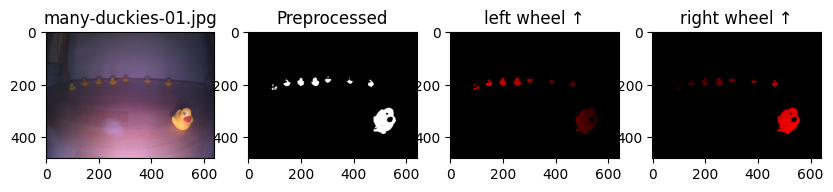

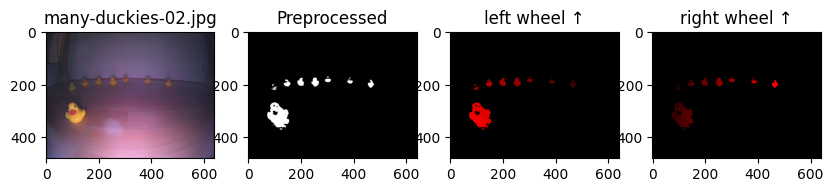

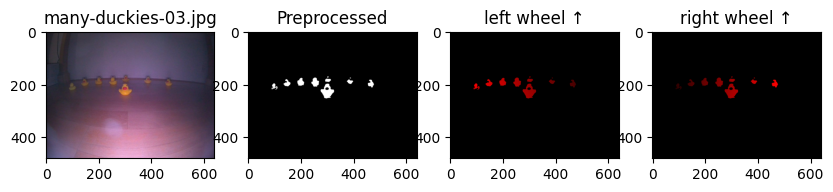

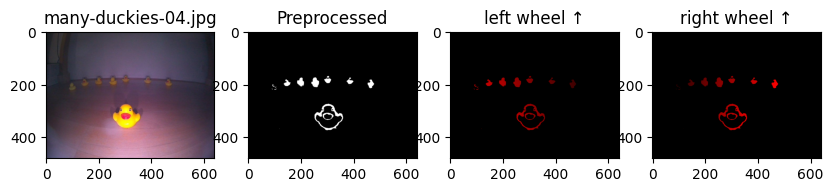

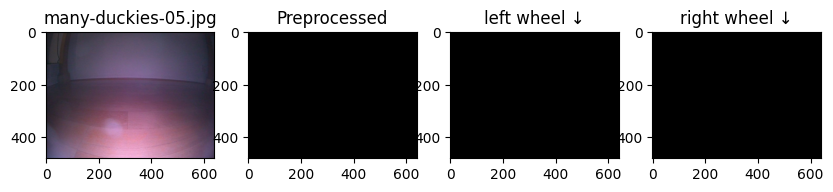

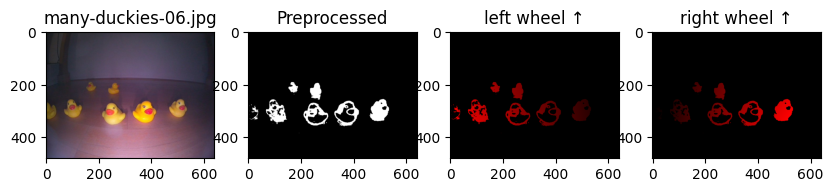

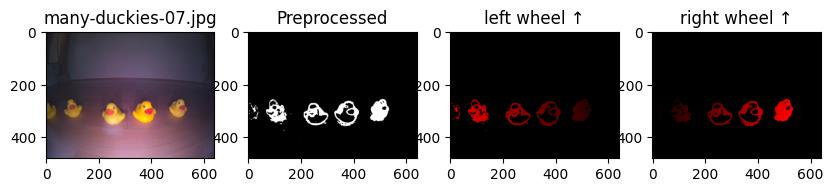

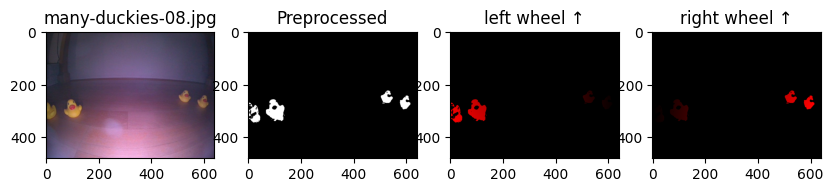

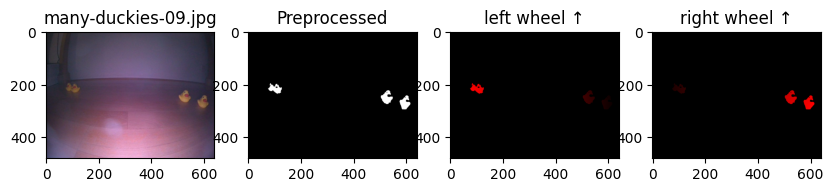

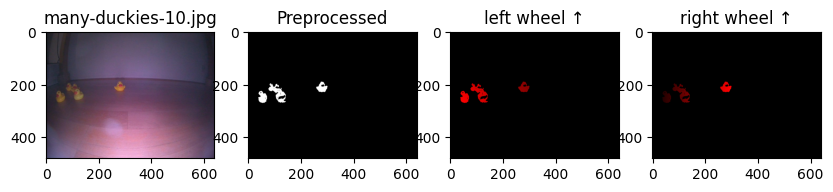

In [6]:
import glob

from packages.preprocessing import preprocess

dirname = '../../../assets/samples/many-duckies'
images = glob.glob(f'{dirname}/*.jpg')

for a in images:
    im = plt.imread(a)
    P = preprocess(im)
    Lim = P * L
    Rim = P * R
    Lsign = np.sum(Lim)
    Rsign = np.sum(Rim)
    f = plt.figure(figsize=(10, 2))
    f.add_subplot(1, 4, 1)
    plt.imshow(im)
    plt.title(os.path.basename(a))
    f.add_subplot(1, 4, 2)
    plt.imshow(P, cmap='gray')
    plt.title("Preprocessed")
    f.add_subplot(1, 4, 3)
    plt.imshow(posneg(Lim))
    plt.title('left wheel ' + ('↑' if Lsign > 0 else '↓'))
    f.add_subplot(1, 4, 4)
    plt.imshow(posneg(Rim), cmap='bwr')
    plt.title('right wheel ' + ('↑' if Rsign > 0 else '↓'))

### Build your agent
Now that the visualizations are set up, you can edit `connections.py` and test your agent.

Use the this command to run the simulation:

`python launch.py --sim --task braitenberg`

While running the simulation, you can configure `gain`,`const` and `threshold` parameters described in the `agent.py`.